# **Chapter1: Data Preprocessing**

This chapter introduces the preprocessing and exploratory analysis steps that usually come before model building. We will work with the Iris dataset, inspect its structure, visualize the main patterns, and prepare the data for later neural-network chapters.


## **Setup and data preparation**

To keep the notebook easy to run locally, this chapter uses the built-in Iris dataset from `sklearn`. The dataset is small, clean, and well suited for demonstrating essential preprocessing, plotting, and train-test preparation steps.


## **Data description**


The Iris flower dataset is a classic multivariate dataset introduced by the British statistician and biologist Ronald Fisher in 1936. It contains measurements from three species of iris flowers and is widely used as an introductory dataset for classification, visualization, and preprocessing tasks.

In this chapter, the dataset serves as a simple and reliable example for exploring how data is inspected before training a machine-learning model.


## **Feature description**


The dataset contains `150` samples and `5` columns: four numeric flower measurements and one class label. Each row corresponds to one flower sample.


> |Variable| Description| 
 |:-------------|:-------------|
 |sepal length| <b>length of the sepal in cm|
 |sepal width| <b>width of the sepal in cm|
 |petal length| <b>length of the petal in cm|
 |petal width| <b>width of the petal in cm|
 |species| <b>iris class label (setosa, versicolor, virginica)|


## **Read data**


## **Read data**

In [1]:
# Required modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import metrics


In [2]:
# Read data

iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.copy()
iris = iris.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width',
    'target': 'species',
})
iris['species'] = iris['species'].map(dict(enumerate(iris_bunch.target_names)))
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris.shape

(150, 5)

**The dataset contains 150 samples and 5 columns. We will now examine it step by step to understand its structure and patterns more clearly.**


## **Preview the dataset**

A quick preview helps us verify the structure of the table and the type of values stored in each column.


In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


## **View summary of dataset**

This section shows the data types and confirms whether any values are missing.


In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## **View the statistical summary of variables**


**These summary statistics give a quick numerical view of the spread and scale of the dataset.**


In [7]:
iris.describe().T 

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [8]:
iris.describe(include = 'object').T 

,count,unique,top,freq
species,150,3,setosa,50


## **Frequency distribution of species(Class)**

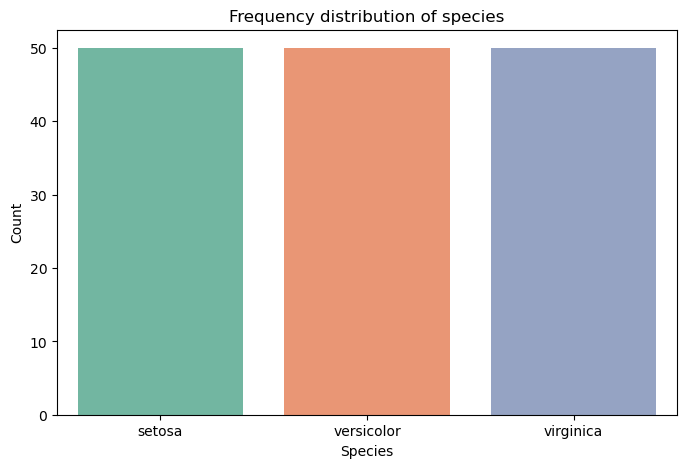

In [9]:
species_counts = iris['species'].value_counts().reset_index()
species_counts.columns = ['species', 'count']

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=species_counts, x='species', y='count', hue='species', palette='Set2', legend=False, ax=ax)
ax.set_title('Frequency distribution of species')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
plt.show()


## **Scatter Plot**

**To delve deeper into examining the relationships, dispersion, and normality of the features**

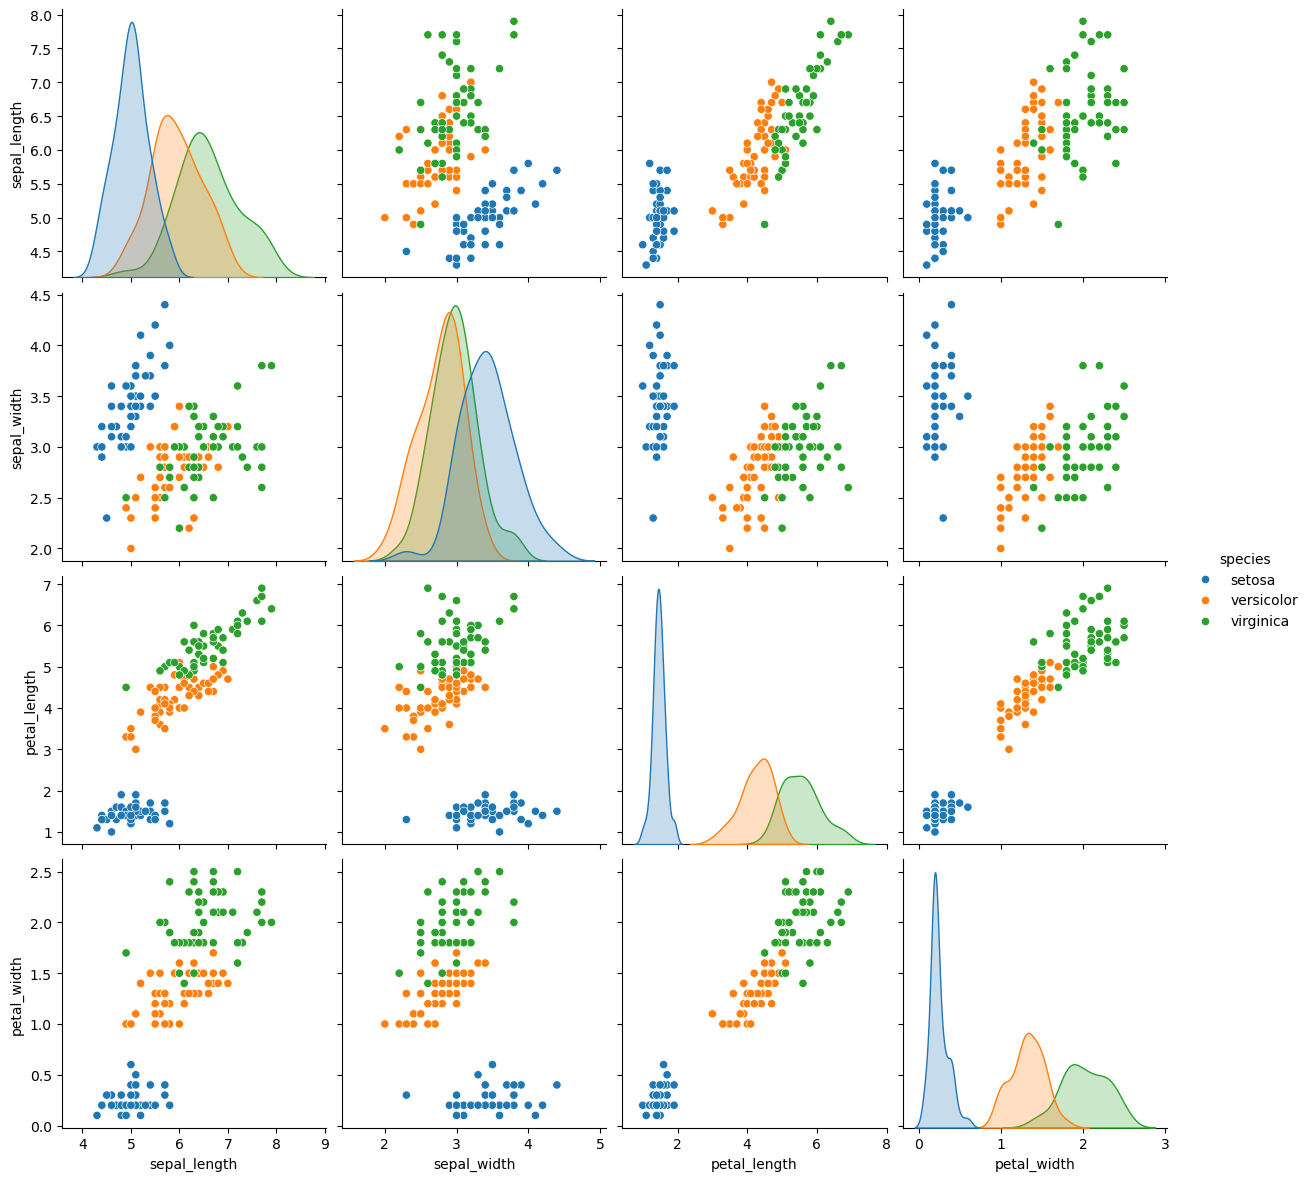

In [10]:
sns.pairplot(iris, hue='species', height=3)
plt.show()


## **Distribution plots**

#### Create a FacetGrid for each feature


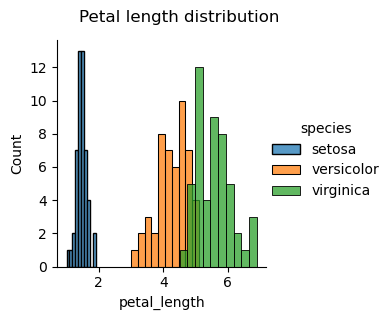

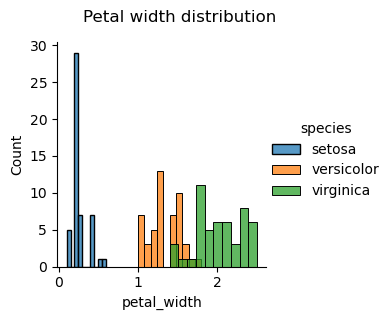

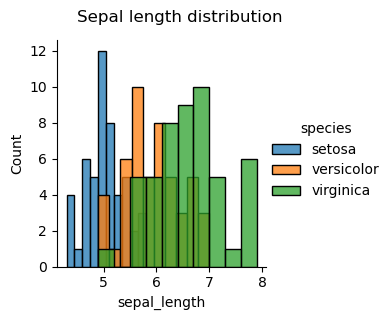

In [11]:
g1 = sns.FacetGrid(iris, hue='species', height=3)
g1.map_dataframe(sns.histplot, x='petal_length', bins=10)
g1.add_legend()
g1.fig.suptitle('Petal length distribution', y=1.05)

g2 = sns.FacetGrid(iris, hue='species', height=3)
g2.map_dataframe(sns.histplot, x='petal_width', bins=10)
g2.add_legend()
g2.fig.suptitle('Petal width distribution', y=1.05)

g3 = sns.FacetGrid(iris, hue='species', height=3)
g3.map_dataframe(sns.histplot, x='sepal_length', bins=10)
g3.add_legend()
g3.fig.suptitle('Sepal length distribution', y=1.05)

plt.show()


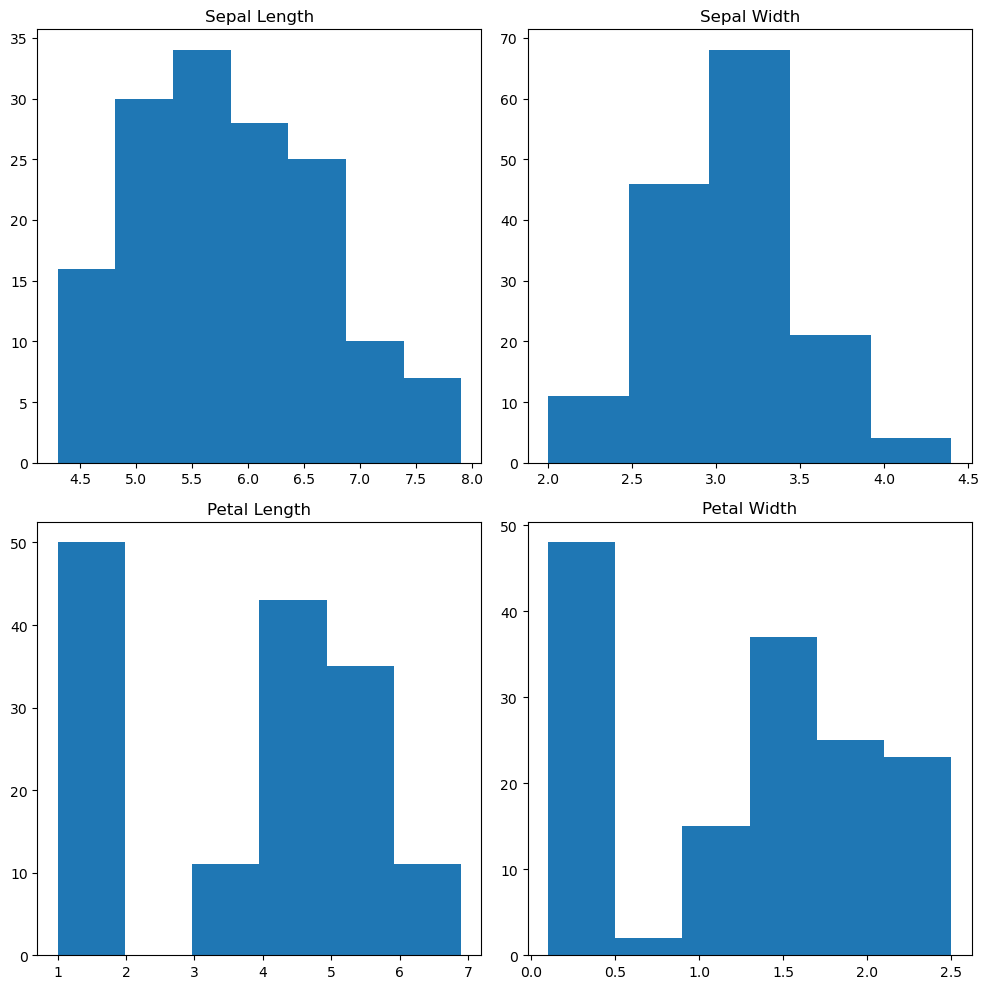

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0,0].set_title('Sepal Length')
axes[0,0].hist(iris['sepal_length'], bins=7)

axes[0,1].set_title('Sepal Width')
axes[0,1].hist(iris['sepal_width'], bins=5)

axes[1,0].set_title('Petal Length')
axes[1,0].hist(iris['petal_length'], bins=6)

axes[1,1].set_title('Petal Width')
axes[1,1].hist(iris['petal_width'], bins=6)

plt.tight_layout()
plt.show()


### **Box Plot**

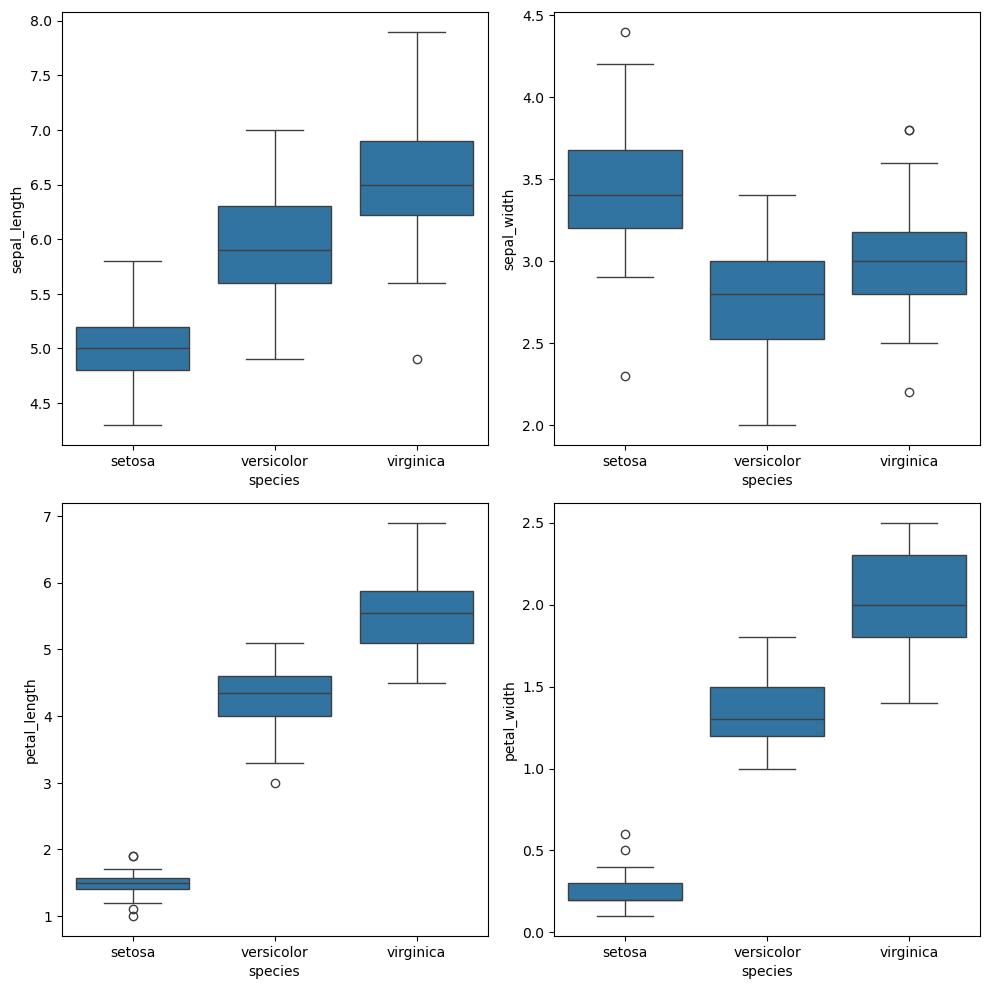

In [13]:
def graph(y):
    sns.boxplot(x='species', y=y, data=iris)

plt.figure(figsize=(10, 10))

plt.subplot(221)
graph('sepal_length')

plt.subplot(222)
graph('sepal_width')

plt.subplot(223)
graph('petal_length')

plt.subplot(224)
graph('petal_width')

plt.tight_layout()
plt.show()


**As evident from the data, it is apparent that some of them like petal_length do not follow a normal distribution.**

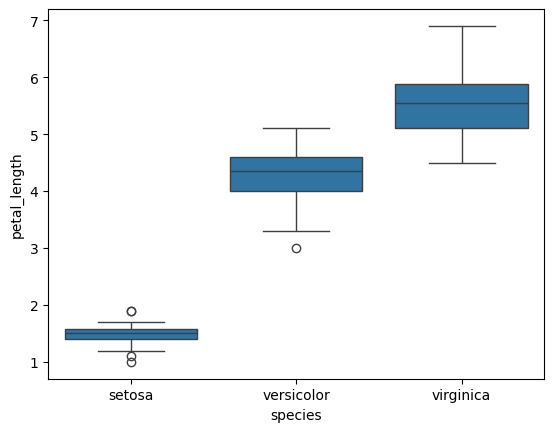

In [14]:
sns.boxplot(x="species",y="petal_length",data=iris)
plt.show()

## **Corrlation**

In [15]:
corrMatrix = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()
corrMatrix


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


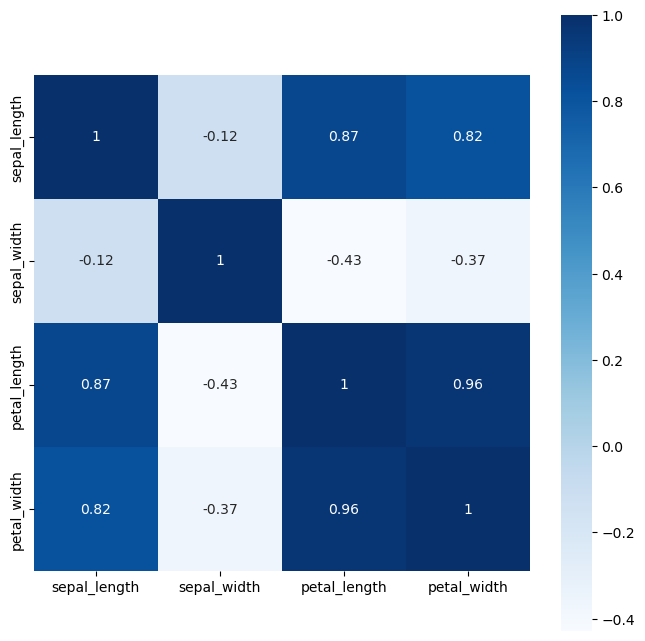

In [16]:
fig = plt.figure(figsize=(8, 8))
sns.heatmap(corrMatrix, annot=True, cmap='Blues', square=True)
plt.show()


**As observed from the correlation matrix results, there are strong correlation among some variables.**

## **Train & Test Split**

In [17]:
df = iris.copy()
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [18]:
X = df.drop(['species'],axis=1)
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [19]:
y = df['species']
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [20]:
# Convert string tags to numbers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
# y_encoder = label_encoder.fit_transform(y)

In [21]:
y
# y_encoder

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [22]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [23]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train


array([[-1.72156775, -0.33210111, -1.34572231, -1.32327558],
       [-1.12449223, -1.22765467,  0.41450518,  0.6517626 ],
       [ 1.14439475, -0.5559895 ,  0.58484978,  0.25675496],
       [-1.12449223,  0.11567567, -1.28894078, -1.45494479],
       [-0.40800161, -1.22765467,  0.13059752,  0.12508575],
       [ 0.54731923, -1.22765467,  0.69841284,  0.91510102],
       [-0.2885865 , -0.77987789,  0.24416059,  0.12508575],
       [ 0.54731923, -0.5559895 ,  0.75519438,  0.38842418],
       [ 2.21913069, -0.10821272,  1.3230097 ,  1.44177787],
       [ 2.21913069,  1.6828944 ,  1.66369889,  1.31010866],
       [ 2.09971558, -0.10821272,  1.60691736,  1.17843945],
       [ 0.18907392, -0.33210111,  0.41450518,  0.38842418],
       [-1.00507713, -2.34709662, -0.15331014, -0.26992188],
       [-0.04975629, -0.77987789,  0.18737906, -0.26992188],
       [-0.04975629, -1.00376628,  0.13059752, -0.00658346],
       [-1.36332244,  0.33956406, -1.23215924, -1.32327558],
       [-0.88566202,  1.

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)
